In [82]:
import numpy as np
import matplotlib.pyplot as plt

In [142]:
import torch
import torch.nn as nn

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.hidden1 = nn.Linear(2, 3)
        self.output = nn.Linear(3, 1)

    def forward(self, x):
        x = torch.relu(self.hidden1(x))
        # x = torch.relu(self.hidden2(x))
        x = torch.sigmoid(self.output(x))
        return x

In [143]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

if device.type == "cuda":
    torch.set_default_device("cuda")
else:
    torch.set_default_device("cpu")

inputs = torch.rand(128, 2, device=device).round()
labels = torch.logical_xor(inputs[:, 0].bool(), inputs[:, 1].bool()).float().unsqueeze(1)
model = SimpleNN().to(device)
loss_function = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [158]:
def reset_parameters(model):
    for layer in model.children():
        if hasattr(layer, 'reset_parameters'):
            layer.reset_parameters()

reset_parameters(model)
# Training loop
N = 5000
N_minibatch = 256
losses = np.empty(N)

for epoch in range(N):
    perm = torch.randperm(inputs.size(0))
    epoch_loss = 0.0

    for i in range(0, inputs.size(0), N_minibatch):
        idx = perm[i:i + N_minibatch]
        batch_inputs = inputs[idx]
        batch_labels = labels[idx]

        optimizer.zero_grad()
        outputs = model(batch_inputs)
        loss = loss_function(outputs, batch_labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * batch_inputs.size(0)

    losses[epoch] = epoch_loss / inputs.size(0)

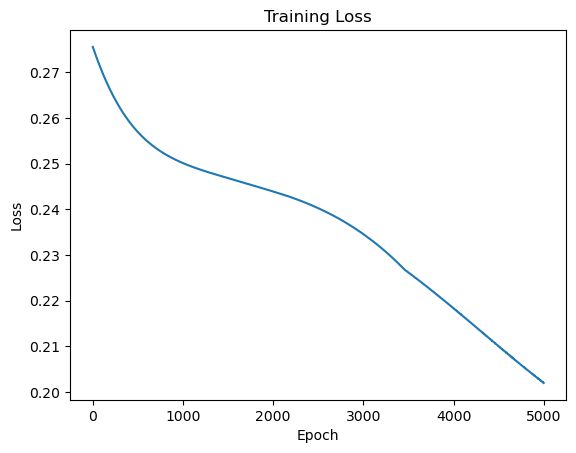

In [159]:
plt.plot(np.arange(N), losses)
# plt.plot(np.arange(N), losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

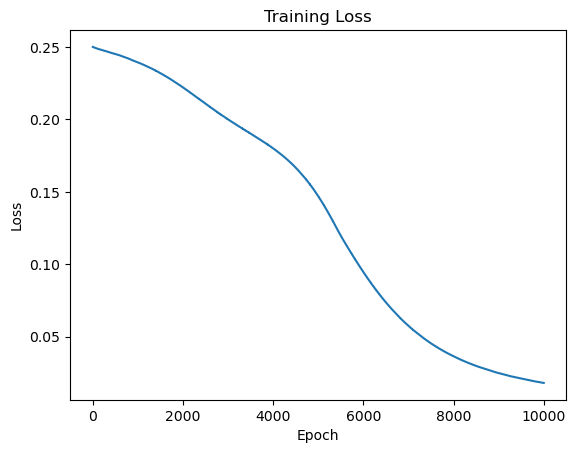

In [ ]:
plt.plot(np.arange(N), losses)
# plt.plot(np.arange(N), losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

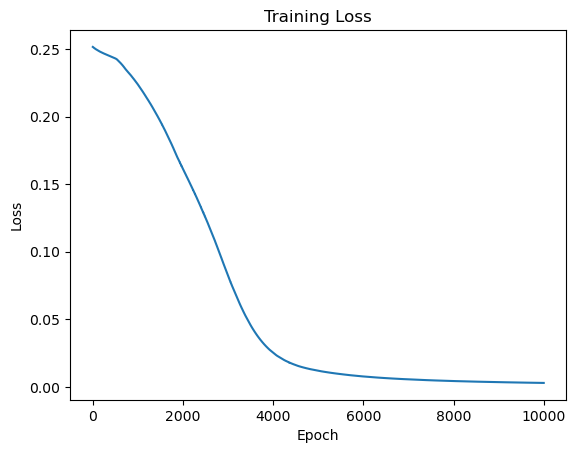

In [ ]:
plt.plot(np.arange(N), losses)
# plt.plot(np.arange(N), losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [87]:
# # Training loop
# N = 10000
# losses = np.empty(N)

# for epoch in range(N):
#     optimizer.zero_grad()
#     outputs = model(inputs)
#     loss = loss_function(outputs, labels)
#     losses[epoch] = loss.item()
#     loss.backward()
#     optimizer.step()

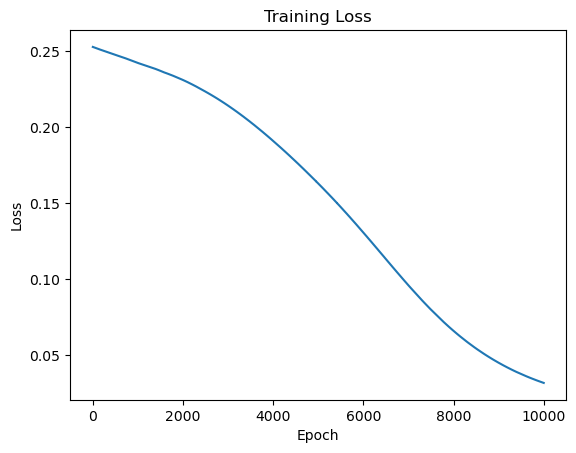

In [13]:
plt.plot(np.arange(N), losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()